# SOB4ES - Red Neuronal Multisalida (MLP)
### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluacion de los modelos

Este notebook implementa una **red neuronal de tipo MLP (Multilayer Perceptron)** con una capa de salida de 11 neuronas, una por cada target.

A diferencia de los modelos basados en arboles, la red neuronal aprende representaciones internas de los datos en capas sucesivas, lo que le permite capturar relaciones no lineales complejas entre las variables de entrada y los targets de salida. Las correlaciones entre targets se capturan de forma implicita al compartir las capas ocultas entre todas las salidas.

La principal limitacion en este contexto es el **tamano del dataset** (~300 muestras de entrenamiento): las redes neuronales generalmente necesitan mas datos para generalizar bien. Se aplican tecnicas de regularizacion (Dropout, L2) para mitigar el sobreajuste.

**Datasets utilizados:**
- `train.csv` - Entrenamiento (70 %, estratificado por pais)
- `test.csv`  - Tuning / validacion cruzada (15 %)
- `eval.csv`  - Evaluacion final imparcial (15 %)

**Estructura del notebook:**
1. Configuracion
2. Carga de datos
3. Tuning de arquitectura e hiperparametros
4. Validacion cruzada
5. Analisis de pesos e importancia de variables
6. Entrenamiento de produccion
7. Evaluacion final

---
## 1. Configuracion del entorno


In [1]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
import itertools

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/mlp/'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)
Path('output/var/').mkdir(parents=True, exist_ok=True)

# Usar GPU si esta disponible, si no CPU

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo de computo: {DEVICE}')

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    #'mo_z',
    #'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]


print('Librerias y variables cargadas correctamente...')

# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}

# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Colormap secuencial (blanco -> azul -> morado) para heatmaps/matrices de confusion
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'sob4es_palette', ['#FFFFFF', PALETTE['purple_light'], PALETTE['purple']]
)


Dispositivo de computo: cuda
Librerias y variables cargadas correctamente...


In [2]:
# Ajuste automatico de n_jobs segun los nucleos disponibles
# Evita saturar la maquina (todos los procesos a la vez con n_jobs=-1)
import os

def get_n_jobs(fraccion=0.75, reserva=1):
    """Calcula un n_jobs seguro dejando al menos `reserva` nucleos libres
    para que el sistema no se vuelva inutilizable durante la ejecucion."""
    n_cpu = os.cpu_count() or 1
    n_usar = max(1, min(int(n_cpu * fraccion), n_cpu - reserva))
    return n_usar

N_JOBS = get_n_jobs()
print(f'Nucleos disponibles: {os.cpu_count()} | n_jobs asignado: {N_JOBS}')

Nucleos disponibles: 20 | n_jobs asignado: 15


## 2. Carga de datos

Se cargan los tres datasets pre-generados (division 70/15/15, estratificada por pais).

| Archivo    | Uso                                      | Filas aprox. |
|------------|------------------------------------------|--------------|
| `train.csv`| Ajuste del modelo                        | 299          |
| `test.csv` | Tuning / validacion cruzada              | 64           |
| `eval.csv` | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la seccion 7.

In [3]:
def cargar_csv(ruta, nombre):
    if not os.path.exists(ruta):
        raise FileNotFoundError(f'No se encontro: {ruta}')
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f'  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas')
    return df

print("Cargando datasets...")
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados...")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}  |  y_eval: {y_eval.shape}")


Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados...
X_train: (299, 32)  |  X_test: (64, 32)  |  X_eval: (65, 32)
y_train: (299, 21)  |  y_test: (64, 21)  |  y_eval: (65, 21)


## 3. Definicion de la arquitectura y tuning

Se define la arquitectura de la red neuronal y se busca la mejor combinacion de hiperparametros mediante una busqueda manual sobre un grid reducido.

La arquitectura base es:
- **Capa de entrada:** 54 neuronas (una por variable predictora)
- **Capas ocultas:** 2-3 capas densas con activacion ReLU
- **Dropout:** para regularizacion y prevencion de sobreajuste
- **Capa de salida:** 11 neuronas lineales (una por target, sin activacion)

Se usa **Adam** como optimizador y **MSE** como funcion de perdida.

In [4]:
class MLPMultiSalida(nn.Module):
    """
    Red neuronal densa con multiples capas ocultas y salida vectorial.
    Cada neurona de salida predice un target independiente,
    pero comparten las capas ocultas, permitiendo aprender correlaciones implicitas.
    """
    def __init__(self, n_inputs, n_outputs, hidden_sizes, dropout_rate):
        super().__init__()
        layers = []
        in_size = n_inputs
        for h in hidden_sizes:
            layers += [
                nn.Linear(in_size, h),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ]
            in_size = h
        layers.append(nn.Linear(in_size, n_outputs))  # capa de salida lineal
        self.red = nn.Sequential(*layers)

    def forward(self, x):
        return self.red(x)


def entrenar_mlp(X_tr, y_tr, X_val, y_val, hidden_sizes, dropout, lr, epochs, batch_size):
    """Entrena un MLP y devuelve el modelo y el R2 de validacion."""
    X_t = torch.tensor(X_tr.values, dtype=torch.float32).to(DEVICE)
    y_t = torch.tensor(y_tr.values, dtype=torch.float32).to(DEVICE)
    X_v = torch.tensor(X_val.values, dtype=torch.float32).to(DEVICE)
    y_v = torch.tensor(y_val.values, dtype=torch.float32).to(DEVICE)

    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)

    model     = MLPMultiSalida(X_tr.shape[1], y_tr.shape[1], hidden_sizes, dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()

    model.train()
    for epoch in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred = model(X_v).cpu().numpy()
    r2 = r2_score(y_val.values, y_pred, multioutput='uniform_average')
    return model, r2


# Grid de hiperparametros a explorar
grid = [
	{'hidden': [32, 16],      'dropout': 0.2, 'lr': 1e-3, 'epochs': 150, 'batch': 16, 'weight_decay': 1e-2},
	{'hidden': [64, 32],      'dropout': 0.3, 'lr': 1e-3, 'epochs': 200, 'batch': 32, 'weight_decay': 1e-2},
	{'hidden': [64, 64],      'dropout': 0.3, 'lr': 5e-4, 'epochs': 200, 'batch': 32, 'weight_decay': 5e-3},
	{'hidden': [128, 64],     'dropout': 0.4, 'lr': 1e-3, 'epochs': 200, 'batch': 32, 'weight_decay': 2e-3},
	{'hidden': [128, 32],     'dropout': 0.3, 'lr': 5e-4, 'epochs': 250, 'batch': 16, 'weight_decay': 1e-3},
	{'hidden': [64, 16, 8],   'dropout': 0.2, 'lr': 1e-3, 'epochs': 200, 'batch': 16, 'weight_decay': 1e-3},
	{'hidden': [64, 32],      'dropout': 0.3, 'lr': 1e-4, 'epochs': 250, 'batch': 16, 'weight_decay': 1e-3},
	{'hidden': [128, 64, 32], 'dropout': 0.4, 'lr': 5e-4, 'epochs': 200, 'batch': 32, 'weight_decay': 5e-3}
]

print('Buscando mejor arquitectura sobre X_train / X_test...\n')
mejor_r2     = -np.inf
mejor_config = None

for cfg in grid:
    _, r2 = entrenar_mlp(
        X_train, y_train, X_test, y_test,
        cfg['hidden'], cfg['dropout'], cfg['lr'], cfg['epochs'], cfg['batch']
    )
    print(f'  hidden={cfg["hidden"]} | dropout={cfg["dropout"]} | '
          f'lr={cfg["lr"]} | epochs={cfg["epochs"]} -> R2 val: {r2:.4f}')
    if r2 > mejor_r2:
        mejor_r2     = r2
        mejor_config = cfg

print(f'\nMejor configuracion: {mejor_config}')
print(f'Mejor R2 de validacion: {mejor_r2:.4f}')
MLP_CONFIG = mejor_config


Buscando mejor arquitectura sobre X_train / X_test...

  hidden=[32, 16] | dropout=0.2 | lr=0.001 | epochs=150 -> R2 val: 0.1208
  hidden=[64, 32] | dropout=0.3 | lr=0.001 | epochs=200 -> R2 val: 0.1524
  hidden=[64, 64] | dropout=0.3 | lr=0.0005 | epochs=200 -> R2 val: 0.1603
  hidden=[128, 64] | dropout=0.4 | lr=0.001 | epochs=200 -> R2 val: 0.1448
  hidden=[128, 32] | dropout=0.3 | lr=0.0005 | epochs=250 -> R2 val: 0.1555
  hidden=[64, 16, 8] | dropout=0.2 | lr=0.001 | epochs=200 -> R2 val: 0.1272
  hidden=[64, 32] | dropout=0.3 | lr=0.0001 | epochs=250 -> R2 val: 0.1154
  hidden=[128, 64, 32] | dropout=0.4 | lr=0.0005 | epochs=200 -> R2 val: 0.1494

Mejor configuracion: {'hidden': [64, 64], 'dropout': 0.3, 'lr': 0.0005, 'epochs': 200, 'batch': 32, 'weight_decay': 0.005}
Mejor R2 de validacion: 0.1603


## 4. Validacion cruzada

Se evalua la robustez de la arquitectura optima con validacion cruzada repetida (5 pliegues x 3 repeticiones) sobre `X_train`. Al ser una red neuronal, el entrenamiento es estocastico: se varan las semillas para obtener una estimacion mas fiable de la varianza del modelo.

Validacion cruzada repetida (15 evaluaciones sobre X_train)...

  Pliegues completados: 5/15  |  R2 medio hasta ahora: 0.1505
  Pliegues completados: 10/15  |  R2 medio hasta ahora: 0.1415
  Pliegues completados: 15/15  |  R2 medio hasta ahora: 0.1480

  R2 medio CV : 0.1480
  Desviacion  : 0.0436
  Minimo      : 0.0295
  Maximo      : 0.2159


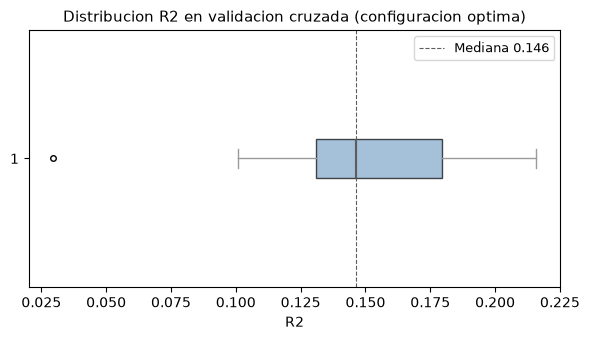

In [5]:
print('Validacion cruzada repetida (15 evaluaciones sobre X_train)...\n')

cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
r2_scores_cv = []

for fold, (train_idx, val_idx) in enumerate(cv_splitter.split(X_train)):
    X_tr_fold = X_train.iloc[train_idx]
    y_tr_fold = y_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]
    y_val_fold = y_train.iloc[val_idx]

    _, r2 = entrenar_mlp(
        X_tr_fold, y_tr_fold, X_val_fold, y_val_fold,
        MLP_CONFIG['hidden'], MLP_CONFIG['dropout'],
        MLP_CONFIG['lr'], MLP_CONFIG['epochs'], MLP_CONFIG['batch']
    )
    r2_scores_cv.append(r2)
    if (fold + 1) % 5 == 0:
        print(f'  Pliegues completados: {fold+1}/15  |  R2 medio hasta ahora: {np.mean(r2_scores_cv):.4f}')

print(f'\n  R2 medio CV : {np.mean(r2_scores_cv):.4f}')
print(f'  Desviacion  : {np.std(r2_scores_cv):.4f}')
print(f'  Minimo      : {np.min(r2_scores_cv):.4f}')
print(f'  Maximo      : {np.max(r2_scores_cv):.4f}')

# Grafico: distribucion R2 CV (boxplot) 
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.boxplot(r2_scores_cv, vert=False, patch_artist=True,
           boxprops=dict(facecolor=PALETTE['blue'], alpha=0.7),
           medianprops=dict(color=PALETTE['gray_dark'], linewidth=1.5),
           whiskerprops=dict(color=PALETTE['gray']),
           capprops=dict(color=PALETTE['gray']),
           flierprops=dict(marker='o', color=PALETTE['gray'], markersize=4))
ax.set_xlabel('R2')
ax.set_title('Distribucion R2 en validacion cruzada (configuracion optima)', fontsize=11)
ax.axvline(np.median(r2_scores_cv), color=PALETTE['gray_dark'], linestyle='--', linewidth=0.8, label=f'Mediana {np.median(r2_scores_cv):.3f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 5. Importancia de variables

Las redes neuronales no tienen una medida de importancia intrinseca como los arboles. Se usa **permutation importance** sobre `X_train`: se baraja aleatoriamente cada variable y se mide cuanto cae el R2, lo que indica cuanto depende el modelo de esa variable.

Entrenando modelo de referencia para calcular importancia...

Top 10 variables más relevantes por permutación (MLP Multisalida):
soil_ph_z                0.1000
dem_elevacion_m_z        0.0601
gee_temp_media_C_z       0.0543
eu_p_z                   0.0516
eu_ph_z                  0.0418
gee_ndvi_verano_z        0.0417
eu_clay_content_z        0.0397
gee_humedad_rel_pct_z    0.0382
eu_silt_content_z        0.0376
bulk_density_z           0.0363

Top 10 variables menos relevantes por permutación (MLP Multisalida):
cu_z                           0.0062
as_z                           0.0128
plot_total_organic_c_z         0.0129
eu_sand_content_z              0.0144
soil_moisture_z                0.0153
pb_z                           0.0195
eu_zn_z                        0.0210
eu_organic_carbon_octop_z      0.0224
dem_pendiente_deg_z            0.0229
eu_water_holding_capacity_z    0.0231

Variables más relevantes exportadas a: './output/var/variables_mas_relevantes_mlp_multisalida.csv'
V

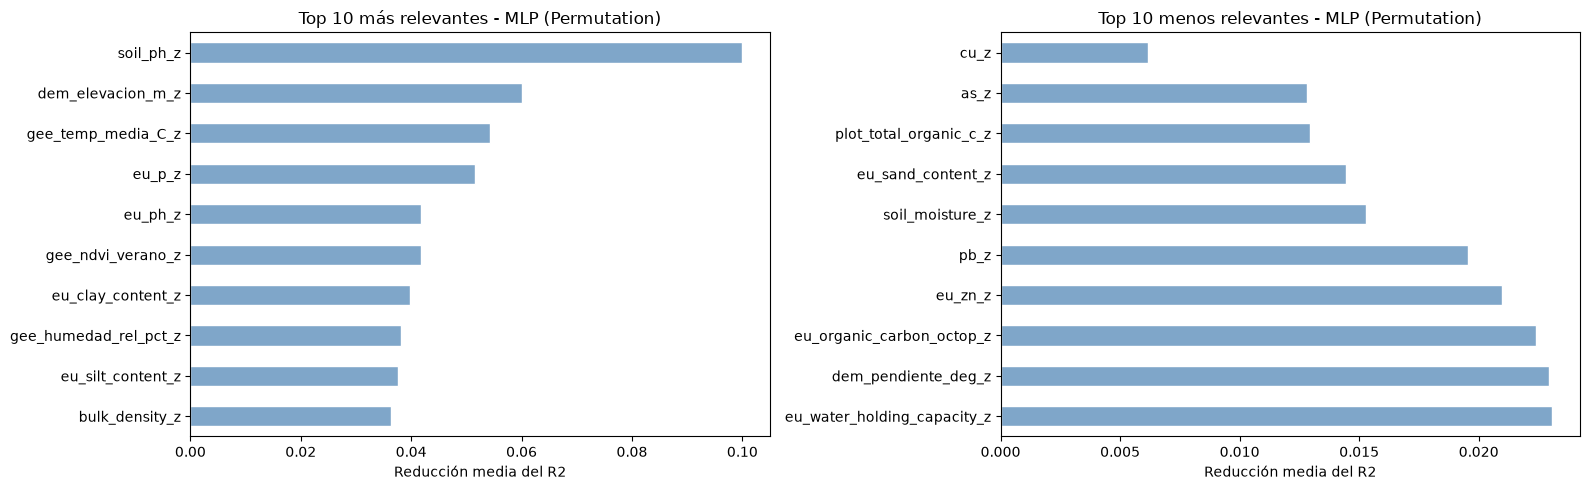

In [6]:
print('Entrenando modelo de referencia para calcular importancia...\n')

# Entrenamos un modelo sobre todo X_train para calcular la importancia
modelo_imp, _ = entrenar_mlp(
    X_train, y_train, X_test, y_test,
    MLP_CONFIG['hidden'], MLP_CONFIG['dropout'],
    MLP_CONFIG['lr'], MLP_CONFIG['epochs'], MLP_CONFIG['batch']
)

# Envolvemos el modelo PyTorch en un wrapper sklearn para usar permutation_importance
class MLPWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model
    def fit(self, X, y):
        return self
    def predict(self, X):
        X_t = torch.tensor(np.array(X), dtype=torch.float32).to(DEVICE)
        self.model.eval()
        with torch.no_grad():
            return self.model(X_t).cpu().numpy()

wrapper = MLPWrapper(modelo_imp)
perm = permutation_importance(
    wrapper, X_train, y_train,
    n_repeats=10, random_state=42
)

importancias = pd.Series(perm.importances_mean, index=FEATURES_AUTORIZADAS)

# Extraer Top 10 variables más y menos relevantes
top10_imp = importancias.nlargest(10)
bottom10_imp = importancias.nsmallest(10)

# Exportación a archivos CSV
ruta_top_csv = './output/var/variables_mas_relevantes_mlp_multisalida.csv'
ruta_bottom_csv = './output/var/variables_menos_relevantes_mlp_multisalida.csv'

top10_imp.to_csv(ruta_top_csv, header=['importancia_permutacion'], index_label='variable')
bottom10_imp.to_csv(ruta_bottom_csv, header=['importancia_permutacion'], index_label='variable')

print('Top 10 variables más relevantes por permutación (MLP Multisalida):')
print(top10_imp.round(4).to_string())

print('\nTop 10 variables menos relevantes por permutación (MLP Multisalida):')
print(bottom10_imp.round(4).to_string())

print(f"\nVariables más relevantes exportadas a: '{ruta_top_csv}'")
print(f"Variables menos relevantes exportadas a: '{ruta_bottom_csv}'")

# Gráficos comparativos de barras (más vs menos relevantes)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico A: más relevantes
top10_imp.sort_values().plot(kind='barh', ax=axes[0], color=PALETTE['blue'], edgecolor='white')
axes[0].set_title('Top 10 más relevantes - MLP (Permutation)', fontsize=12)
axes[0].set_xlabel('Reducción media del R2')
axes[0].set_ylabel('')

# Gráfico B: menos relevantes
bottom10_imp.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color=PALETTE['blue'], edgecolor='white')
axes[1].set_title('Top 10 menos relevantes - MLP (Permutation)', fontsize=12)
axes[1].set_xlabel('Reducción media del R2')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 6. Entrenamiento de produccion

Se entrena un ensamble de 5 redes neuronales con semillas distintas. Al ser el entrenamiento estocastico, cada red converge a una solucion ligeramente diferente. Promediar las predicciones reduce la varianza y mejora la estabilidad del modelo final.

In [7]:
print('Entrenamiento de produccion (ensamble de 5 redes neuronales)...')
print('-' * 70)

global_start = time.time()
NUM_REDES    = 5

for seed_id in range(NUM_REDES):
    t0 = time.time()
    torch.manual_seed(42 + seed_id)
    np.random.seed(42 + seed_id)

    model, r2_test = entrenar_mlp(
        X_train, y_train, X_test, y_test,
        MLP_CONFIG['hidden'], MLP_CONFIG['dropout'],
        MLP_CONFIG['lr'], MLP_CONFIG['epochs'], MLP_CONFIG['batch']
    )

    ruta = os.path.join(MODELS_DIR, f'mlp_prod_{seed_id}.pt')
    torch.save(model.state_dict(), ruta)
    print(f'  Red {seed_id+1}/5 | R2 test: {r2_test:.4f} | guardada en {ruta} ({time.time()-t0:.1f}s)')

# Guardamos la configuracion para poder reconstruir la arquitectura al cargar
joblib.dump(MLP_CONFIG, os.path.join(MODELS_DIR, 'mlp_config.pkl'))

print('-' * 70)
print(f'Produccion completada en {(time.time()-global_start)/60:.1f} minutos.')


Entrenamiento de produccion (ensamble de 5 redes neuronales)...
----------------------------------------------------------------------
  Red 1/5 | R2 test: 0.1511 | guardada en output/models/mlp/mlp_prod_0.pt (1.2s)
  Red 2/5 | R2 test: 0.1281 | guardada en output/models/mlp/mlp_prod_1.pt (1.4s)
  Red 3/5 | R2 test: 0.1614 | guardada en output/models/mlp/mlp_prod_2.pt (1.2s)
  Red 4/5 | R2 test: 0.1244 | guardada en output/models/mlp/mlp_prod_3.pt (1.2s)
  Red 5/5 | R2 test: 0.1426 | guardada en output/models/mlp/mlp_prod_4.pt (1.4s)
----------------------------------------------------------------------
Produccion completada en 0.1 minutos.


## 7. Evaluacion final y prueba de funcionamiento

Esta seccion tiene dos partes:

**Parte A - Evaluacion final**
Se mide por primera vez el rendimiento sobre `eval.csv`. Se muestran metricas globales (promedio sobre los 11 targets) y R2 individual por target.

**Parte B - Smoke test**
Se verificia que el pipeline funciona de extremo a extremo con 3 filas reales de `eval.csv`.

---
**Como leer el indice Shannon H':**
Cada target es el indice de diversidad de Shannon de un grupo biologico distinto. El valor va de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad). Un valor tipico en suelos agricolas europeos se situa entre `1.5` y `2.5`.

Evaluacion final sobre eval.csv
------------------------------------------------------------
  R2   global: -0.0941
  RMSE global: 0.9680 puntos de Shannon H'
  MAE  global: 0.7086 puntos de Shannon H'

  R2 por target:
    nematode_shannon_z             0.0665
    macro_shannon_z                0.2324
    earthworm_shannon_z            0.3459
    orib_shannon_z                 0.2560
    meso_shannon_z                 -0.4332
    coll_shannon_z                 -1.3272
    bac_shannon_z                  -0.0873
    fun_shannon_z                  -0.1062
    euk_shannon_z                  0.1607
    oomy_shannon_z                 0.1135
    cerc_shannon_z                 -0.0999
    macro_order_richness_z         0.3312
    earthworm_richness_z           0.4394
    orib_species_richness_z        0.2877
    meso_species_richness_z        -0.2059
    coll_species_richness_z        -2.2044
    bac_asv_richness_z             -0.1153
    fun_asv_richness_z             0.0075
    euk_asv_rich

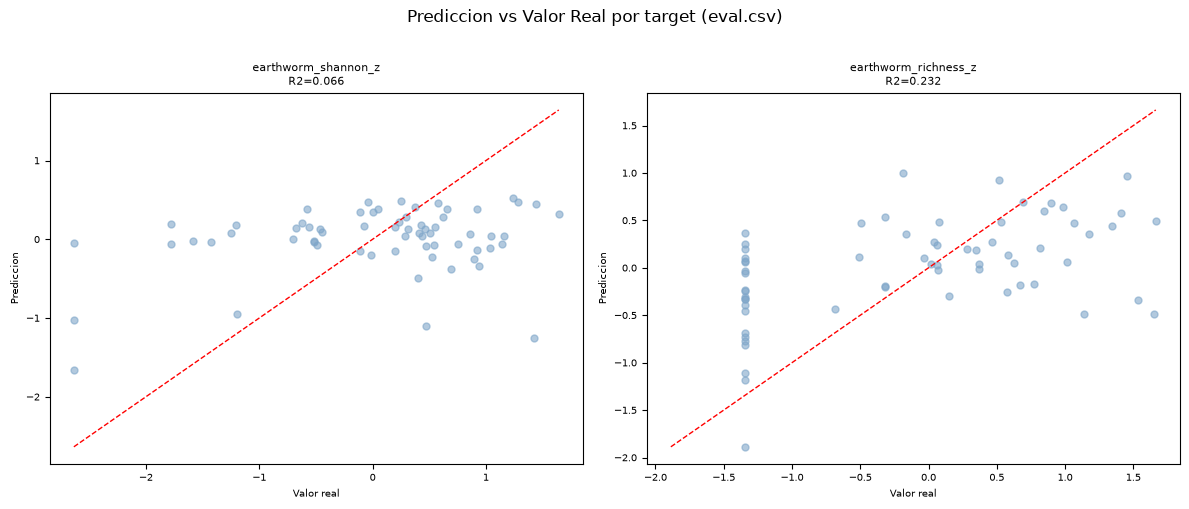

In [8]:
NUM_REDES = 5


# Evaluacion final

print('Evaluacion final sobre eval.csv')
print('-' * 60)

# Cargamos la configuracion y reconstruimos cada red para cargar sus pesos
cfg_prod = joblib.load(os.path.join(MODELS_DIR, 'mlp_config.pkl'))

preds_eval = []
for seed_id in range(NUM_REDES):
    model = MLPMultiSalida(
        len(FEATURES_AUTORIZADAS), len(TARGETS),
        cfg_prod['hidden'], cfg_prod['dropout']
    ).to(DEVICE)
    model.load_state_dict(torch.load(os.path.join(MODELS_DIR, f'mlp_prod_{seed_id}.pt'), map_location=DEVICE))
    model.eval()
    with torch.no_grad():
        X_eval_t = torch.tensor(X_eval.values, dtype=torch.float32).to(DEVICE)
        pred     = model(X_eval_t).cpu().numpy()
    preds_eval.append(pred)

y_pred_eval = np.mean(preds_eval, axis=0)
y_true_eval = y_eval.values

r2_global   = r2_score(y_true_eval, y_pred_eval, multioutput='uniform_average')
rmse_global = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval, multioutput='uniform_average'))
mae_global  = mean_absolute_error(y_true_eval, y_pred_eval, multioutput='uniform_average')

print(f'  R2   global: {r2_global:.4f}')
print(f'  RMSE global: {rmse_global:.4f} puntos de Shannon H\'')
print(f'  MAE  global: {mae_global:.4f} puntos de Shannon H\'')

print('\n  R2 por target:')
r2_por_target = r2_score(y_true_eval, y_pred_eval, multioutput='raw_values')
for t, r2 in zip(TARGETS, r2_por_target):
    print(f'    {t:30} {r2:.4f}')

# Smoke test con datos reales

print('\nSmoke test - Inferencia con datos reales (Shannon & Richness)')
print('-' * 75)

try:
    df_new_data      = X_eval.sample(n=3, random_state=42)
    indices_elegidos = df_new_data.index

    votos = []
    for seed_id in range(NUM_REDES):
        model = MLPMultiSalida(
            len(FEATURES_AUTORIZADAS), len(TARGETS),
            cfg_prod['hidden'], cfg_prod['dropout']
        ).to(DEVICE)
        model.load_state_dict(torch.load(os.path.join(MODELS_DIR, f'mlp_prod_{seed_id}.pt'), map_location=DEVICE))
        model.eval()
        with torch.no_grad():
            X_new_t = torch.tensor(df_new_data.values, dtype=torch.float32).to(DEVICE)
            pred    = model(X_new_t).cpu().numpy()
        votos.append(pred)
        
        idx_sha = TARGETS.index('earthworm_shannon_z')
        idx_ric = TARGETS.index('earthworm_richness_z')
        print(f'  Red {seed_id+1} | Fila {indices_elegidos[0]}: Sha={pred[0, idx_sha]:.3f}, Ric={pred[0, idx_ric]:.3f} | '
              f'Fila {indices_elegidos[1]}: Sha={pred[1, idx_sha]:.3f}, Ric={pred[1, idx_ric]:.3f}')

    consenso  = np.mean(votos, axis=0)
    idx_earth_sha = TARGETS.index('earthworm_shannon_z')
    idx_earth_ric = TARGETS.index('earthworm_richness_z')

    print('-' * 75)
    print('  Resultados detallados por muestra (Métrica: Shannon):')
    print('-' * 75)
    for i, idx in enumerate(indices_elegidos):
        pred_val = consenso[i, idx_earth_sha]
        real_val = y_eval.loc[idx, 'earthworm_shannon_z']
        print(f'    Fila {idx:<4} | Predicción: {pred_val:.4f} | Valor Real: {real_val:.4f} | Error: {abs(pred_val - real_val):.4f}')

    print('-' * 75)
    print('  Resultados detallados por muestra (Métrica: Richness):')
    print('-' * 75)
    for i, idx in enumerate(indices_elegidos):
        pred_val = consenso[i, idx_earth_ric]
        real_val = y_eval.loc[idx, 'earthworm_richness_z']
        print(f'    Fila {idx:<4} | Predicción: {pred_val:.4f} | Valor Real: {real_val:.4f} | Error: {abs(pred_val - real_val):.4f}')

    print('-' * 75)
    print('\nSmoke test superado. El pipeline MLP predictivo (Shannon + Richness) funciona correctamente.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: prediccion vs valor real por target
targets = ['earthworm_shannon_z', 'earthworm_richness_z']
n_targets = len(targets)
n_cols    = 2
n_rows    = (n_targets + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12,5))
axes = axes.flatten()

for i, t in enumerate(targets):
    ax = axes[i]
    ax.scatter(y_true_eval[:, i] if y_true_eval.ndim > 1 else y_true_eval,
               y_pred_eval[:, i] if y_pred_eval.ndim > 1 else y_pred_eval,
               alpha=0.6, s=25, color=PALETTE['blue'])
    lim = [min((y_true_eval[:, i] if y_true_eval.ndim > 1 else y_true_eval).min(),
               (y_pred_eval[:, i] if y_pred_eval.ndim > 1 else y_pred_eval).min()),
           max((y_true_eval[:, i] if y_true_eval.ndim > 1 else y_true_eval).max(),
               (y_pred_eval[:, i] if y_pred_eval.ndim > 1 else y_pred_eval).max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    r2_t = r2_score(
        y_true_eval[:, i] if y_true_eval.ndim > 1 else y_true_eval,
        y_pred_eval[:, i] if y_pred_eval.ndim > 1 else y_pred_eval
    )
    ax.set_title(f'{t}\nR2={r2_t:.3f}', fontsize=8)
    ax.set_xlabel('Valor real', fontsize=7)
    ax.set_ylabel('Prediccion', fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Prediccion vs Valor Real por target (eval.csv)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()